In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from astropy import stats
from astropy.time import Time
from astropy.table import Table
from kpf_etc.etc import kpf_photon_noise_estimate

import matplotlib.pyplot as plt

In [2]:
# Modified versions of functions in Jack Lubin's kpf_empirical_etc repo
def to_array_or_nan(x, n=4):
    if isinstance(x, np.ndarray):
        return x
    else:
        return np.full(n, np.nan)

def prepare_data(data_file, m1=-1, m2=30, mjd1=60200, mjd2=62000):
    ata = pd.read_csv(data_file)
    ata['TOTCORR2'] = ata['TOTCORR'].str.split().apply(lambda x: np.array(x, dtype=float))
    ata['TOTCORR2_fixed'] = ata['TOTCORR2'].apply(to_array_or_nan)
    new_cols = ['TOTCORR_1', 'TOTCORR_2', 'TOTCORR_3', 'TOTCORR_4']
    ata[new_cols] = pd.DataFrame(ata['TOTCORR2_fixed'].tolist(), index=ata.index)
    # add a "sum" column
    ata['TOTCORR_SUM'] = ata[new_cols].sum(axis=1, min_count=4)

    # apply masks 
    if mjd1:
        date_mask1 = ata['MJD-OBS'] > mjd1
    if mjd2:
        date_mask2 = ata['MJD-OBS'] <= mjd2
    no_short_exp_mask = ata['ELAPSED'] > 10
    magmask = (ata['GAIAMAG'] > m1) & (ata['GAIAMAG'] <= m2)
    magmask2 = (ata['GAIAMAG'] > 9.2) & (ata['GAIAMAG'] < 9.5) #because of missing labeling in OBs, this was a default value, so remove all stars with this value as the data is not usable.
    count_range = (ata['TOTCORR_SUM'] > 0) & (ata['TOTCORR_SUM'] < 2*10**9)
    count_range1 = (ata['TOTCORR_1'] > 0) & (ata['TOTCORR_1'] < 2*10**9)
    count_range2 = (ata['TOTCORR_2'] > 0) & (ata['TOTCORR_2'] < 2*10**9)
    count_range3 = (ata['TOTCORR_3'] > 0) & (ata['TOTCORR_3'] < 2*10**9)
    count_range4 = (ata['TOTCORR_4'] > 0) & (ata['TOTCORR_4'] < 2*10**9)

    ata = ata[date_mask1&date_mask2&no_short_exp_mask&magmask&~magmask2&count_range&count_range1&count_range2&count_range3&count_range4]
    return ata

In [3]:
data_file = 'data/Feb2026_anonymized.csv'
data = prepare_data(data_file)
bright = prepare_data(data_file, m1=-1, m2=5.3)
faint = prepare_data(data_file, m1=5.3, m2=30)
len(data), len(bright), len(faint)

(7595, 3620, 3975)

In [4]:
# KPFERA 1.0
SM1start = Time('2024-02-03')
SM1end = Time('2024-02-23')
# KPFERA 2.0
SM2start = Time('2024-10-31')
SM2end = Time('2024-11-20')
# KPFERA 2.5
SM3start = Time('2025-03-28')
SM3end = Time('2025-04-23')
# KPFERA 3.0
SM4start = Time('2025-08-29')
SM4end = Time('2025-10-27')
# KPFERA 4.0


dataByEra = {'1.0': prepare_data(data_file, m1=-1, m2=30, mjd1=60200, mjd2=SM1start.mjd),
             '2.0': prepare_data(data_file, m1=-1, m2=30, mjd1=SM1end.mjd, mjd2=SM2start.mjd),
             '2.5': prepare_data(data_file, m1=-1, m2=30, mjd1=SM2end.mjd, mjd2=SM3start.mjd),
             '3.0': prepare_data(data_file, m1=-1, m2=30, mjd1=SM3end.mjd, mjd2=SM4start.mjd),
             '4.0': prepare_data(data_file, m1=-1, m2=30, mjd1=SM4end.mjd, mjd2=Time.now().mjd),
            }
dataForExpMeter = prepare_data(data_file, m1=-1, m2=30, mjd1=SM1end.mjd, mjd2=Time.now().mjd)

In [5]:
# KPF-etc limits:
#- Teff: 2700 - 6600 Kelvin
#- Vmag: 2 - 19
#- Texp: 10 - 3600 seconds

validTeff_mask = (data['TARGTEFF'] > 2700) & (data['TARGTEFF'] < 6600)
invalidTeff = data[~validTeff_mask]
print(len(data), len(invalidTeff), len(invalidTeff)/len(data))

7595 268 0.03528637261356155


# Histogram of Observing and/or Stellar Parameters

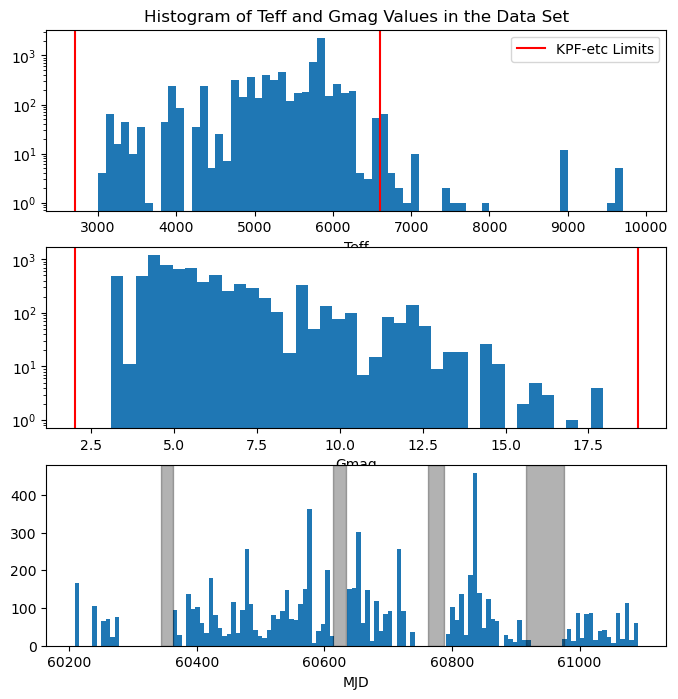

In [6]:
plt.figure(figsize=(8,8))

plt.subplot(3,1,1)
plt.title('Histogram of Teff and Gmag Values in the Data Set')
bins=np.arange(2700,10000,100)
plt.hist(data['TARGTEFF'], bins=bins, log=True)
plt.axvline(2700, color='r', label='KPF-etc Limits')
plt.axvline(6600, color='r')
plt.xlabel('Teff')
plt.legend(loc='best')

plt.subplot(3,1,2)
plt.hist(data['GAIAMAG'], bins=40, log=True)
plt.axvline(2, color='r', label='KPF-etc Limits')
plt.axvline(19, color='r')
plt.xlabel('Gmag')

plt.subplot(3,1,3)
nd = max(data['MJD-OBS'])-min(data['MJD-OBS'])
plt.hist(data['MJD-OBS'], bins=int(nd/7))
plt.axvspan(SM1start.mjd, SM1end.mjd, color='k', alpha=0.3, label='Servicing Mission')
plt.axvspan(SM2start.mjd, SM2end.mjd, color='k', alpha=0.3)
plt.axvspan(SM3start.mjd, SM3end.mjd, color='k', alpha=0.3)
plt.axvspan(SM4start.mjd, SM4end.mjd, color='k', alpha=0.3)
plt.xlabel('MJD')

plt.show()

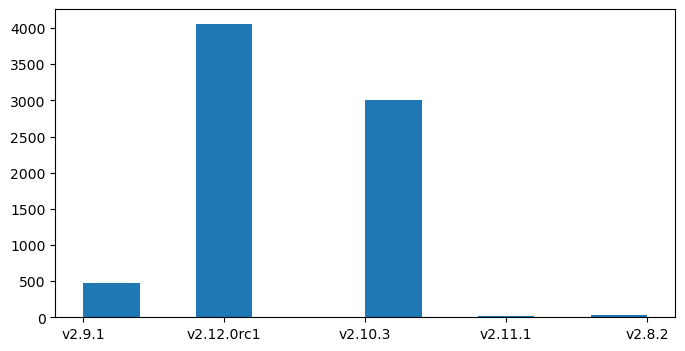

In [7]:
plt.figure(figsize=(8,4))
plt.hist(data['DRPTAGL2'])
plt.show()

In [8]:
A_per_pix = 0.0166
A_per_order = 4080*A_per_pix
percentile = 95 # 60

# Determine Exposure Meter Zero Points

In [9]:
def calculate_ExpMeter_zero_point(data, EMbin=1, percentile=95, plot=False):
    Gmag = np.array(data['GAIAMAG'])
    if EMbin == 'all':
        EMflux = data['TOTCORR_SUM']
    else:
        EMflux = data[f'TOTCORR_{EMbin}']
    EMinstmag = np.array(-2.5*np.log10(EMflux / data['EXPTIME']))

    mask = np.isfinite(Gmag) & np.isfinite(EMinstmag)
    EMzps = Gmag[mask] - EMinstmag[mask]
    EMZP = np.percentile(EMzps, percentile)
    # print(f"Exposure Meter Zero Point = {EMZP:.2f}")

    if plot:
        plt.figure(figsize=(10,3))

        # plt.subplot(2,1,1)
        plt.title(f'Exposure Meter Zero Point (bin {EMbin}) = {EMZP:.2f}')
        n, bins, p = plt.hist(EMzps, bins=100, density=True, label='Zero Points')
        # plt.hist(EMzps[~validTeff_mask], bins=bins, density=True, alpha=0.4, label='Zero Points (ETC invalid)')
        plt.ylabel(f'Density (N={len(EMzps)})')
        plt.axvline(EMZP, color='k', alpha=0.5, label='Nominal Zero Point')
        # plt.axvspan(EMZP, EMZP-2/2.5, color='g', alpha=0.2, label='band1')
        # plt.axvspan(EMZP-2/2.5, EMZP-4/2.5, color='y', alpha=0.2, label='band2')
        plt.grid()
        plt.legend(loc='best')
        plt.xlim(12,24)
        
        # plt.subplot(2,1,2)
        # plt.hist(EMzps, bins=100, density=True, cumulative=True, label='Zero Points')
        # plt.ylabel(f'Cumulative Density (N={len(EMzps)})')
        # plt.axvline(EMZP, color='k', alpha=0.5, label='Nominal Zero Point')
        # # plt.axvspan(EMZP, EMZP-2/2.5, color='g', alpha=0.2, label='band1')
        # # plt.axvspan(EMZP-2/2.5, EMZP-4/2.5, color='y', alpha=0.2, label='band2')
        # plt.grid()
        # plt.legend(loc='best')
        plt.xlabel('Zero Point (mag)')
        
        plt.show()

    return float(EMZP), EMzps

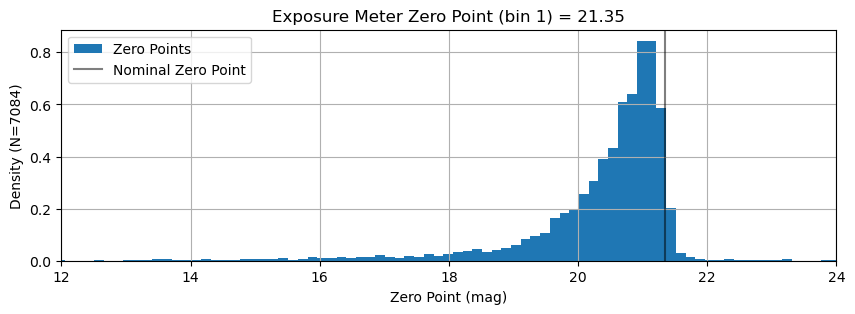

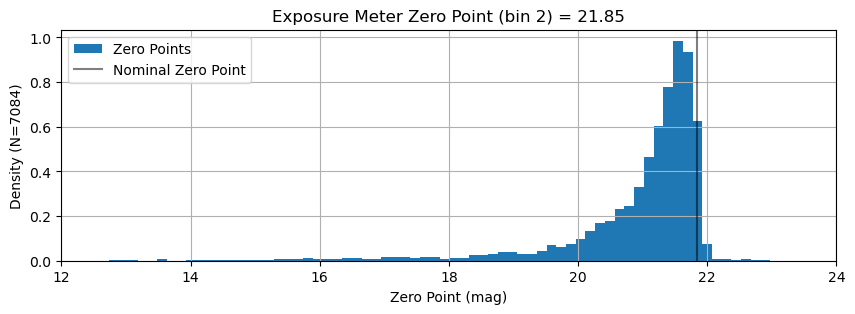

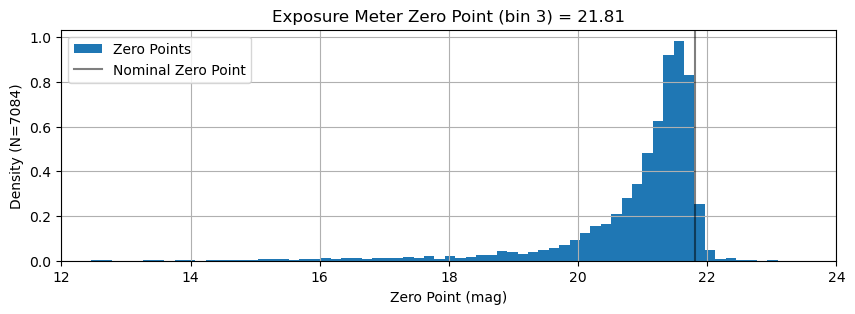

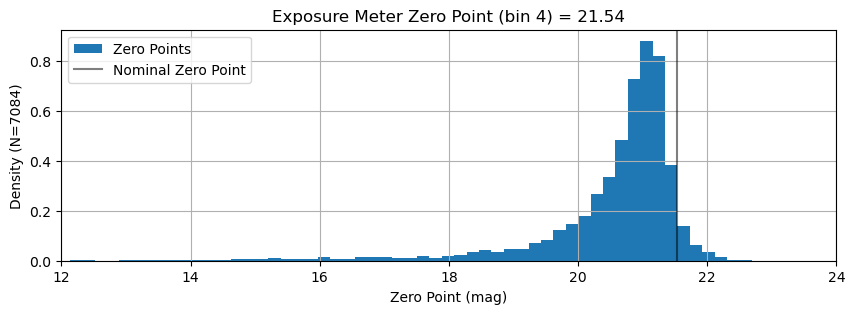

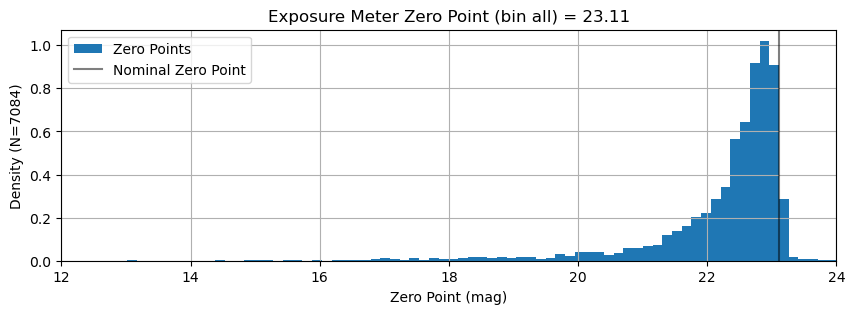

In [10]:
EMZeroPoint = {}
EMZeroPoints = {}
for EMbin in [1, 2, 3, 4, 'all']:
    EMZeroPoint[EMbin], EMZeroPoints[EMbin] = calculate_ExpMeter_zero_point(dataForExpMeter, EMbin=EMbin, percentile=95, plot=True)

In [11]:
EMZeroPoint

{1: 21.352451658353417,
 2: 21.846229524916005,
 3: 21.809188833345296,
 4: 21.53844641054678,
 'all': 23.113411319890474}

## Check for Zero Point Evolution in Time

In [12]:
def evolution_of_EMZP(EMbin):
    ZeroPointByEra = {}
    ZeroPointsByEra = {}
    NFilesByEra = {}

    for era in ['2.0', '2.5', '3.0', '4.0']:
        NFilesByEra[era] = len(dataByEra[era])
        ZeroPointByEra[era], ZeroPointsByEra[era] = calculate_ExpMeter_zero_point(dataByEra[era], EMbin=EMbin, plot=False)
    return ZeroPointByEra

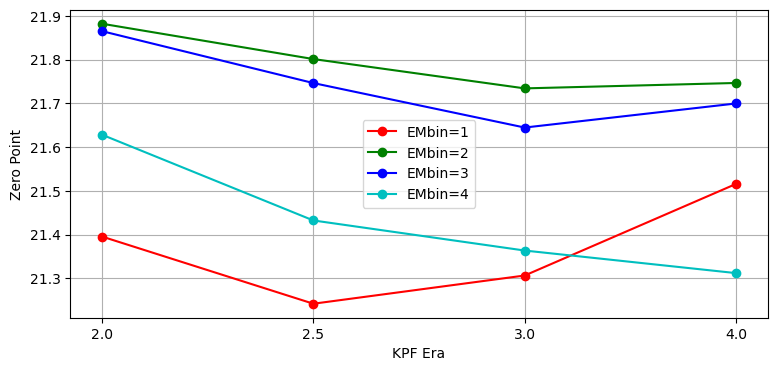

In [13]:
plt.figure(figsize=(9,4))
for i,EMbin in enumerate([1, 2, 3, 4]):
    c = ['r', 'g', 'b', 'c', 'k'][i]
    ZeroPointByEra = evolution_of_EMZP(EMbin)
    plt.plot(ZeroPointByEra.keys(), [ZeroPointByEra[k] for k in ZeroPointByEra.keys()], f'{c}o-', label=f'EMbin={EMbin}')
plt.xlabel('KPF Era')
plt.ylabel('Zero Point')
plt.legend(loc='best')
plt.grid()
plt.show()

# Determine Zero Points for Spectrograph

In [14]:
def calculate_instrument_zero_point(data, wav='652', percentile=95, plot=False, photons=None):
    Gmag = np.array(data['GAIAMAG'])
    if photons is None:
        photons = (data[f'SNRSC{wav}'].values)**2 # photons / pix
    instmag = np.array(-2.5*np.log10(photons / data['EXPTIME']))
    mask = np.isfinite(Gmag) & np.isfinite(instmag)
    zps = Gmag[mask] - instmag[mask]
    ZP = np.percentile(zps, percentile)
    # print(f"Instrument ({wav}nm) Zero Point = {ZP:.2f}")

    if plot:
        plt.figure(figsize=(10,3))
        
        # plt.subplot(2,1,1)
        plt.title(f'Instrument ({wav} nm) Zero Point = {ZP:.2f}')
        n, bins, p = plt.hist(zps, bins=100, density=True, label='Zero Points')
        plt.ylabel(f'Density (N={len(zps)})')
        plt.axvline(ZP, color='k', alpha=0.5, label='Nominal Zero Point')
        # plt.axvspan(ZP, ZP-2/2.5, color='g', alpha=0.2, label='band1')
        # plt.axvspan(ZP-2/2.5, ZP-4/2.5, color='y', alpha=0.2, label='band2')
        plt.grid()
        plt.xlim(7,17)
        plt.legend(loc='best')
        
        # plt.subplot(2,1,2)
        # plt.hist(zps, bins=100, density=True, cumulative=True, label='Zero Points')
        # plt.ylabel(f'Cumulative Density (N={len(zps)})')
        # plt.axvline(ZP, color='k', alpha=0.5, label='Nominal Zero Point')
        # plt.axvspan(ZP, ZP-2/2.5, color='g', alpha=0.2, label='band1')
        # plt.axvspan(ZP-2/2.5, ZP-4/2.5, color='y', alpha=0.2, label='band2')
        # plt.grid()
        # plt.legend(loc='best')
        plt.xlabel('Zero Point (mag)')
        
        plt.show()
    
    return float(ZP), zps

In [15]:
instwavs = ['452', '548', '652', '747', '852']
ZeroPoint = {}
ZeroPoints = {}

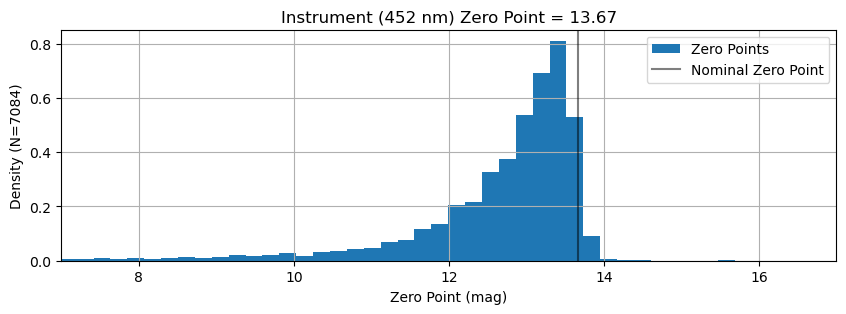

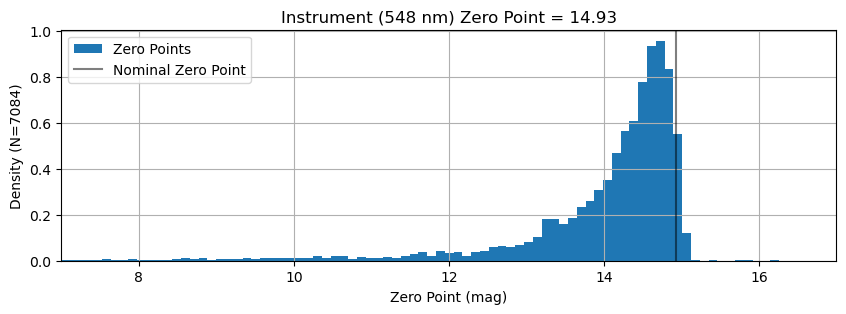

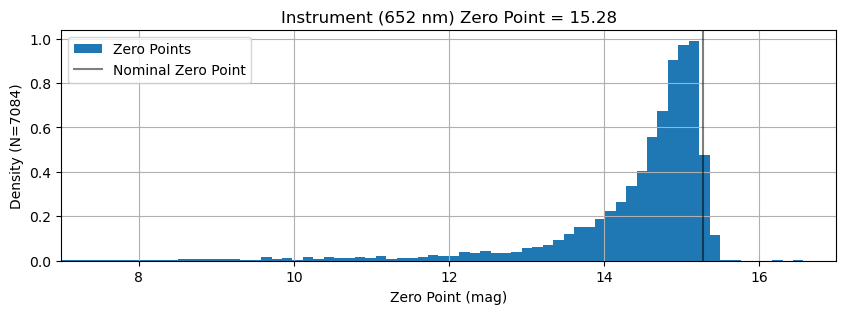

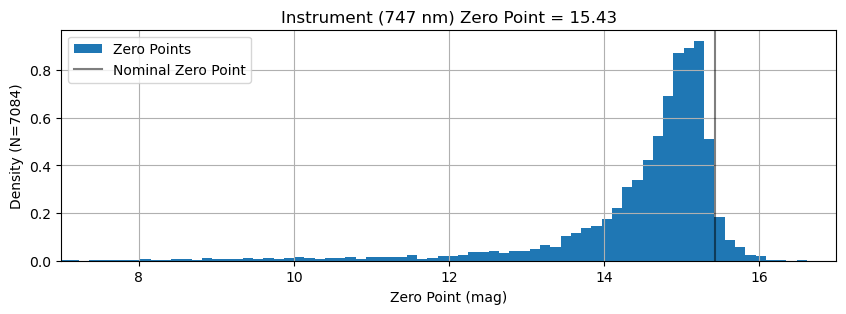

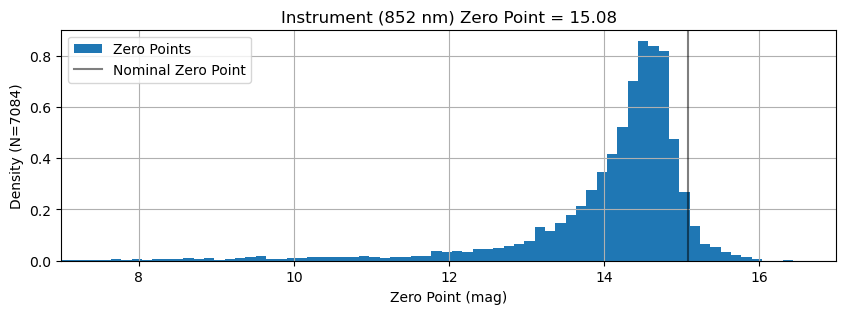

In [16]:
for wav in instwavs:
    ZeroPoint[wav], ZeroPoints[wav] = calculate_instrument_zero_point(dataForExpMeter, wav=wav, plot=True)

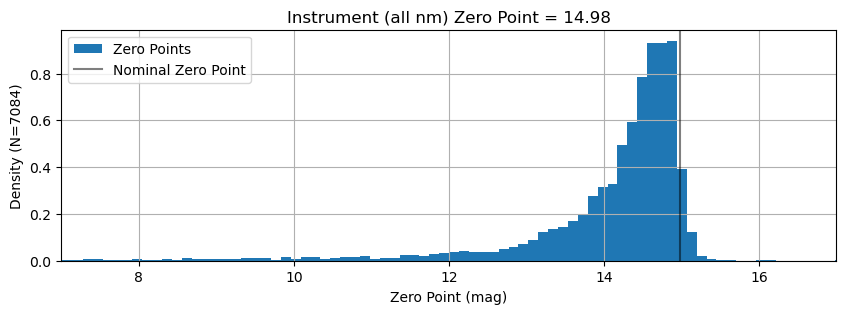

In [17]:
photons = 0
for key in ['SNRSC452', 'SNRSC548', 'SNRSC652', 'SNRSC747', 'SNRSC852']:
    photons += (dataForExpMeter[key].values)**2 # photons / pix
photons /= 5

ZeroPoint['all'], ZeroPoints['all'] = calculate_instrument_zero_point(dataForExpMeter, wav='all', plot=True, photons=photons)

In [18]:
ZeroPoint

{'452': 13.667874179810761,
 '548': 14.933385239040264,
 '652': 15.275873159657648,
 '747': 15.427752915829013,
 '852': 15.08216419251189,
 'all': 14.979199275822635}

## Check for Zero Point Evolution in Time

In [19]:
def evolution_of_ZP(wav):
    ZeroPointByEra = {}
    ZeroPointsByEra = {}
    NFilesByEra = {}

    for era in ['1.0', '2.0', '2.5', '3.0', '4.0']:
        NFilesByEra[era] = len(dataByEra[era])
        ZeroPointByEra[era], ZeroPointsByEra[era] = calculate_instrument_zero_point(dataByEra[era], wav=wav, plot=False)
    return ZeroPointByEra


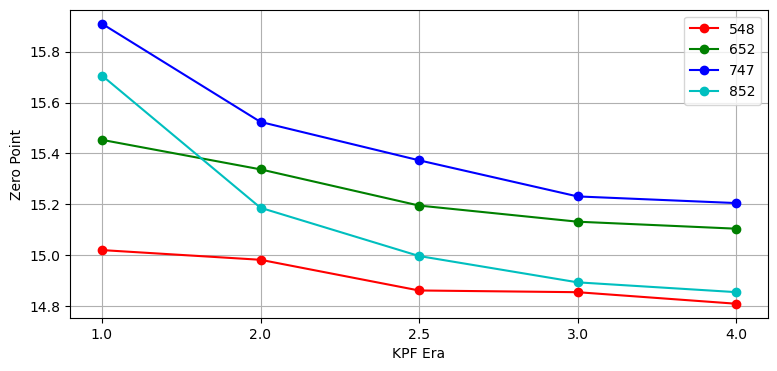

In [20]:
plt.figure(figsize=(9,4))
for i,wav in enumerate(instwavs[1:]):
    c = ['r', 'g', 'b', 'c', 'k'][i]
    ZeroPointByEra = evolution_of_ZP(wav)
    plt.plot(ZeroPointByEra.keys(), [ZeroPointByEra[k] for k in ZeroPointByEra.keys()], f'{c}o-', label=f'{wav}')
plt.xlabel('KPF Era')
plt.ylabel('Zero Point')
plt.legend(loc='best')
plt.grid()
plt.show()

In [21]:
evolution_of_ZP(instwavs[0])

{'1.0': 13.669995845149044,
 '2.0': 13.695533454952194,
 '2.5': 13.58278577274581,
 '3.0': 13.645965749666527,
 '4.0': 13.565194395868497}

### Bin By Day

In [22]:
list(set(data['DRPTAGL2']))

['v2.11.1', 'v2.8.2', 'v2.12.0rc1', 'v2.10.3', 'v2.9.1']

/Users/joshw/miniforge3/envs/py313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/joshw/miniforge3/envs/py313/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


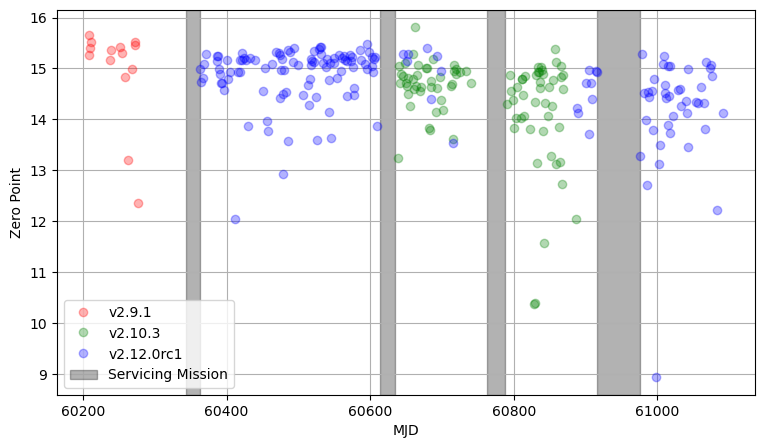

In [23]:
zp, zps = calculate_instrument_zero_point(data, wav='747')
mjd = np.array([int(d) for d in data['MJD-OBS']])

plt.figure(figsize=(9,5))

drpvs = ['v2.9.1', 'v2.10.3', 'v2.12.0rc1']
for i,drpv in enumerate(drpvs):
    color = ['r', 'g', 'b'][i]
    for j,day in enumerate(set(mjd)):
        wday = np.where((mjd == day) & (data['DRPTAGL2'] == drpv))
        # print(drpv, day, wday)
        day_zp = np.median(zps[wday])
        if j == 0:
            plt.plot(day, day_zp, f'{color}o', alpha=0.3, label=f'{drpvs[i]}')
        else:
            plt.plot(day, day_zp, f'{color}o', alpha=0.3)
plt.axvspan(SM1start.mjd, SM1end.mjd, color='k', alpha=0.3, label='Servicing Mission')
plt.axvspan(SM2start.mjd, SM2end.mjd, color='k', alpha=0.3)
plt.axvspan(SM3start.mjd, SM3end.mjd, color='k', alpha=0.3)
plt.axvspan(SM4start.mjd, SM4end.mjd, color='k', alpha=0.3)
plt.xlabel('MJD')
plt.ylabel('Zero Point')
plt.grid()
plt.legend(loc='best')
plt.show()

# Exposure Meter vs. Spectrograph Zero Points

Exposure Meter Wavelength Bins: `498.12 604.38 710.62 816.88`

In [24]:
def find_best_ExpMeterBin(instwav, plot=True):
    EMbins = [1, 2, 3, 4, 'all']
    EMwav = {1: ' 498nm',
             2: ' 604nm',
             3: ' 710nm',
             4: ' 817nm',
             'all': ''}

    if plot: plt.figure(figsize=(12,4))
    comparison_stddev = []
    comparison_median = []
    for i,EMbin in enumerate(EMbins):
        ZPdiff = ZeroPoints[instwav] - EMZeroPoints[EMbin]
        mean, median, stddev = stats.sigma_clipped_stats(ZPdiff)
        comparison_stddev.append(float(stddev))
        comparison_median.append(float(median))
    
        plt.subplot(2,3,i+1)
        plt.title(f'{instwav}nm-EM{EMbin}: dZP={median:.2f}, std={stddev:.3f} mag')
        bins = np.arange(median-10*stddev, median+10*stddev, 0.01)
        plt.hist(ZPdiff, bins=bins, color='b', alpha=0.4,
                 density=True, log=True)
        plt.ylabel(f'Density (N={len(ZPdiff)})')
        plt.xlabel(f'')
    
    plt.show()
    best_EMbin = EMbins[np.argmin(comparison_stddev)]
    print(best_EMbin, comparison_stddev)
    return best_EMbin, EMwav[best_EMbin].strip()

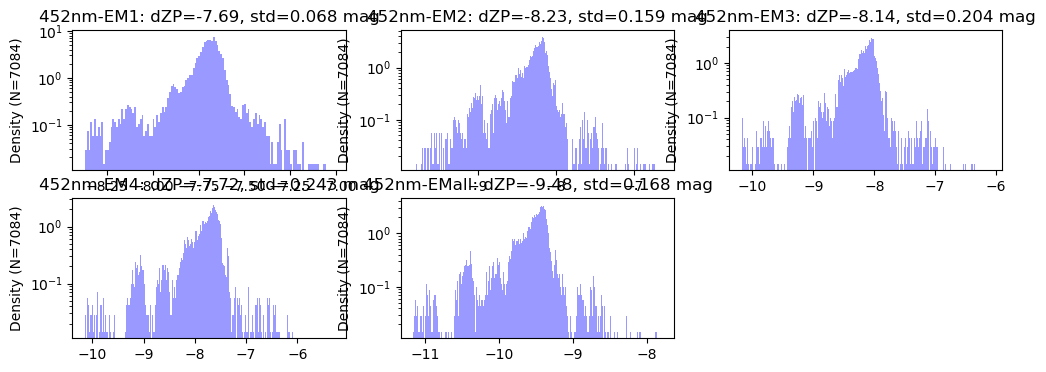

1 [0.068119497352036, 0.15937750842841797, 0.2042282191286287, 0.2429053090385928, 0.16812078439120243]


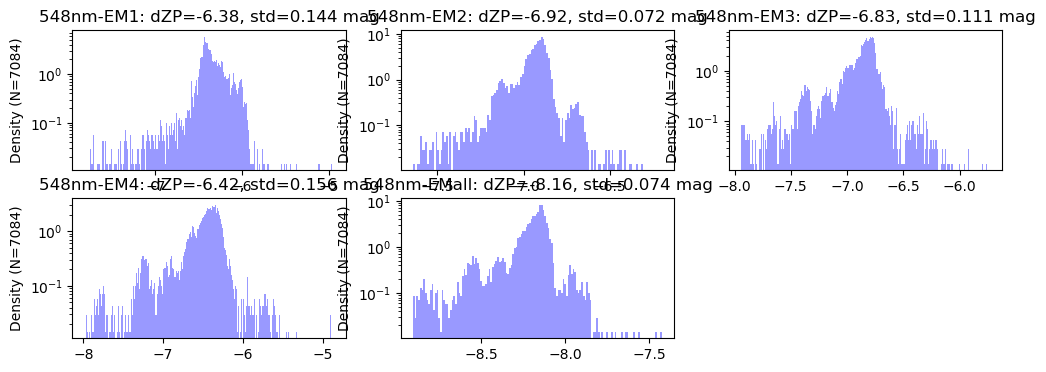

2 [0.14360643021118377, 0.07226413181552327, 0.11091392698144222, 0.15620803382545617, 0.07405311271640731]


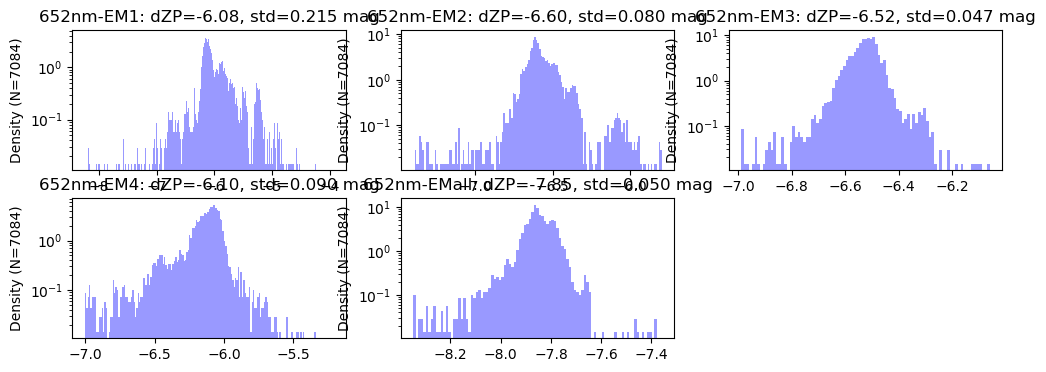

3 [0.2153860103063896, 0.08006947279232952, 0.04673530804919559, 0.08982519665443321, 0.049705736609177355]


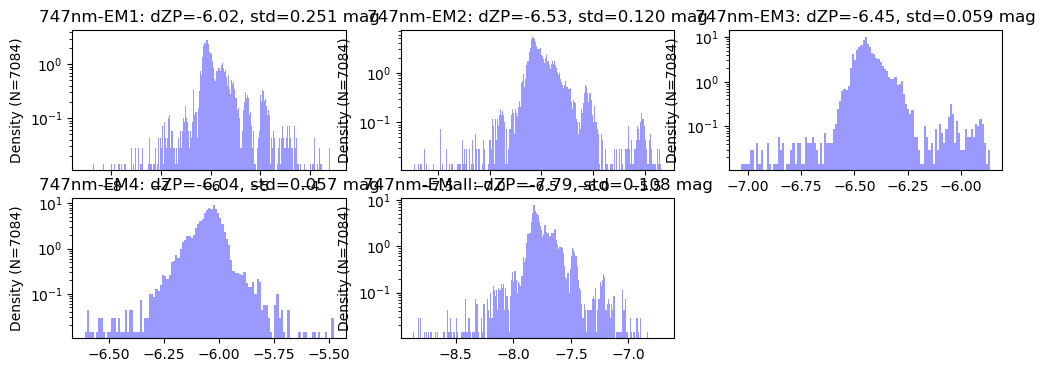

4 [0.25077008712770815, 0.12020645875760945, 0.05867519992333995, 0.05677642505083691, 0.10821206363026217]


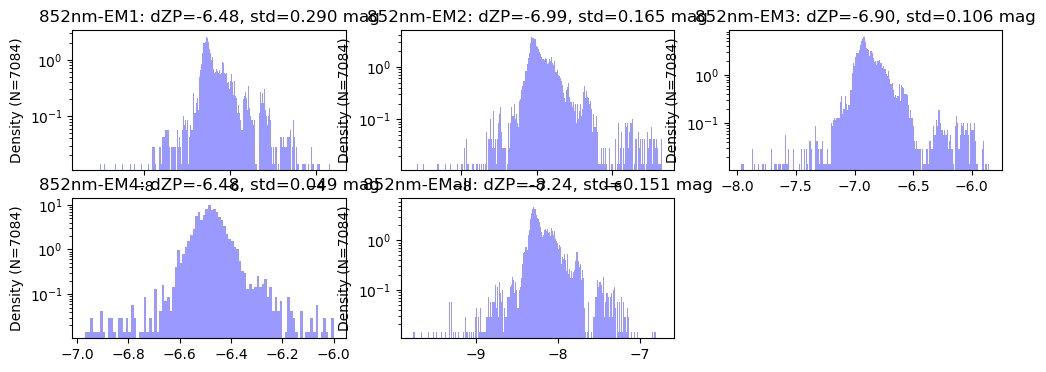

4 [0.2901096644202865, 0.16455674765925063, 0.1063021923491574, 0.0486868676484878, 0.15137620480072467]


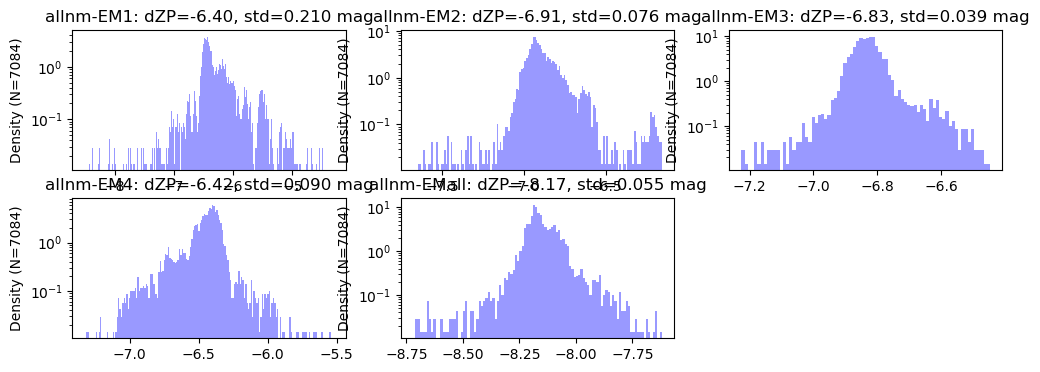

3 [0.21006639531931168, 0.07618576783280796, 0.03925483881007536, 0.09017700206472355, 0.055209480126242653]


In [25]:
best_EMbin = {}
for instwav in ZeroPoint.keys():
    EMbin, EMwav = find_best_ExpMeterBin(instwav, plot=True)
    best_EMbin[instwav] = EMbin

In [26]:
best_EMbin

{'452': 1, '548': 2, '652': 3, '747': 4, '852': 4, 'all': 3}

# Zero Point Based ETC

In [27]:
    # peak_photon_ratios = {'498.125': 0.104,
    #                       '604.375': 0.116,
    #                       '710.625': 0.087,
    #                       '816.875': 0.116}
    # expmeter_threshold = 1e6*Mphotons_per_A/peak_photon_ratios[band]
# EMADU = photons_per_A/ratio
for wav in instwavs:
    dZP = ZeroPoint[wav] - EMZeroPoint[best_EMbin[wav]]
    ratio = 10**(-dZP/2.5)
    print(f"For {wav} nm, Inst to ExpMeter ZP difference = {dZP:.2f}, flux conversion = {ratio:.0f}")

For 452 nm, Inst to ExpMeter ZP difference = -7.68, flux conversion = 1185
For 548 nm, Inst to ExpMeter ZP difference = -6.91, flux conversion = 582
For 652 nm, Inst to ExpMeter ZP difference = -6.53, flux conversion = 411
For 747 nm, Inst to ExpMeter ZP difference = -6.11, flux conversion = 278
For 852 nm, Inst to ExpMeter ZP difference = -6.46, flux conversion = 382


In [28]:
def ZPETC(Gmag, exptime, instwav='652', EMbin=2):
    assert instwav in ZeroPoint.keys()
    assert EMbin in EMZeroPoint.keys()
    photons = float(exptime*10**((Gmag - ZeroPoint[instwav])/-2.5))
    EM_ADU = float(exptime*10**((Gmag - EMZeroPoint[EMbin])/-2.5))
    return photons, EM_ADU


def EMThreshold(photons, instwav='652', EMbin=2):
    assert instwav in ZeroPoint.keys()
    assert EMbin in EMZeroPoint.keys()
    ZPdiff = ZeroPoint[instwav] - EMZeroPoint[EMbin]
    EM_ADU = photons*10**(-ZPdiff/2.5)
    return EM_ADU

In [29]:
photons, EMADU = ZPETC(10, 60, instwav='747', EMbin=3)
photons, EMADU

(8897.180815163292, 3175607.242262741)

In [30]:
EMADU2 = EMThreshold(photons, instwav='747', EMbin=3)
EMADU2/EMADU

0.9999999999999991

# Slowdown Factor

In [31]:
def plot_slowdowns(instwav):
    EMbin = best_EMbin[instwav]
    instfluxes = (dataForExpMeter[f'SNRSC{instwav}'].array)**2 # photons / pix
    if EMbin == 'all':
        EMfluxes = dataForExpMeter[f'TOTCORR_SUM'].array
    else:
        EMfluxes = dataForExpMeter[f'TOTCORR_{EMbin}'].array
    
    Gmags = dataForExpMeter['GAIAMAG'].array
    exptimes = dataForExpMeter['ELAPSED'].array
    
    slowdowns = np.array([ZPETC(Gmags[i], exptimes[i], instwav=instwav, EMbin=EMbin)[0]/instfluxes[i] for i in range(len(dataForExpMeter))])
    EMslowdowns = np.array([ZPETC(Gmags[i], exptimes[i], instwav=instwav, EMbin=EMbin)[1]/EMfluxes[i] for i in range(len(dataForExpMeter))])

    bins = np.arange(0,10,0.1)
    
    plt.figure(figsize=(10,7))
    
    plt.subplot(4,1,1)
    plt.title(f'Instrument Slowdowns Calulated at {instwav} nm')
    plt.hist(slowdowns, bins=bins, density=True, color='b', label='Spectrograph')
    plt.axvline(1, color='k', alpha=0.5, label='Nominal')
    plt.axvspan(1, 2, color='g', alpha=0.2, label='band1')
    plt.axvspan(2, 4, color='y', alpha=0.2, label='band2')
    plt.grid()
    plt.legend(loc='best')
    plt.ylabel(f'Density (N={len(slowdowns)})')
    
    plt.subplot(4,1,2)
    plt.hist(EMslowdowns, bins=bins, density=True, color='g', label='ExpMeter')
    plt.axvline(1, color='k', alpha=0.5, label='Nominal')
    plt.axvspan(1, 2, color='g', alpha=0.2, label='band1')
    plt.axvspan(2, 4, color='y', alpha=0.2, label='band2')
    plt.grid()
    plt.legend(loc='best')
    plt.ylabel(f'Density (N={len(slowdowns)})')

    plt.subplot(4,1,3)
    plt.hist(EMslowdowns, bins=bins, density=True, color='g', cumulative=True, label='ExpMeter')
    plt.axvline(1, color='k', alpha=0.5, label='Nominal')
    plt.axvspan(1, 2, color='g', alpha=0.2, label='band1')
    plt.axvspan(2, 4, color='y', alpha=0.2, label='band2')
    plt.grid()
    plt.legend(loc='best')
    plt.xlabel('Slowdown Factor')
    plt.ylabel(f'Cumulative Density')
    
    plt.subplot(4,1,4)
    bins = np.arange(0,3,0.025)
    plt.hist(slowdowns/EMslowdowns, bins=bins, density=True, log=False, color='c')
    plt.axvline(1)
    plt.grid()
    plt.xlabel('Ratio: slowdown/EMslowdown')
    
    plt.show()

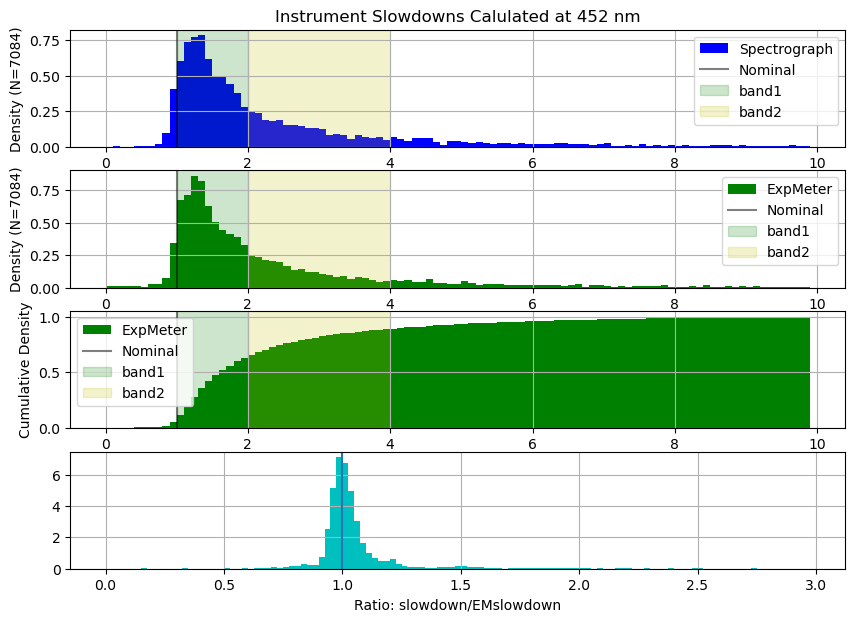

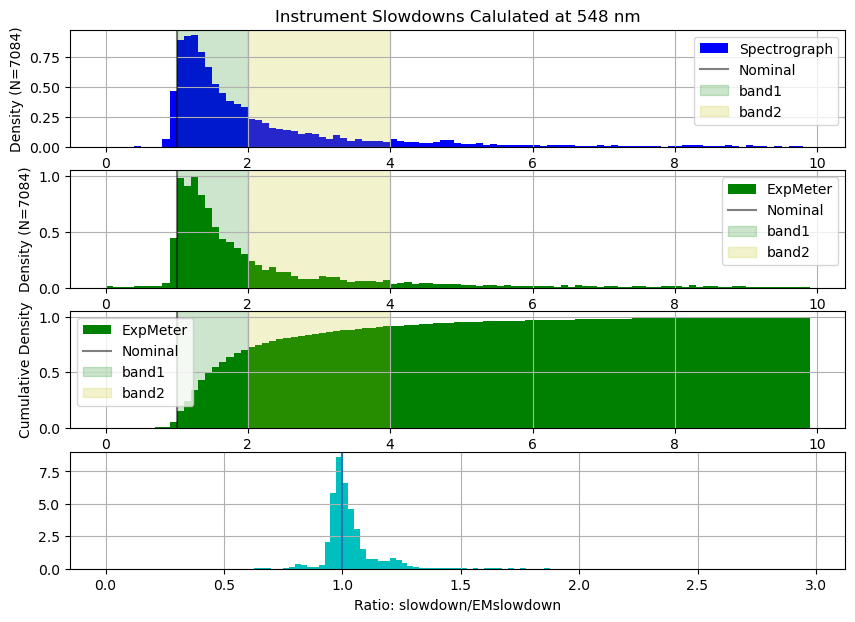

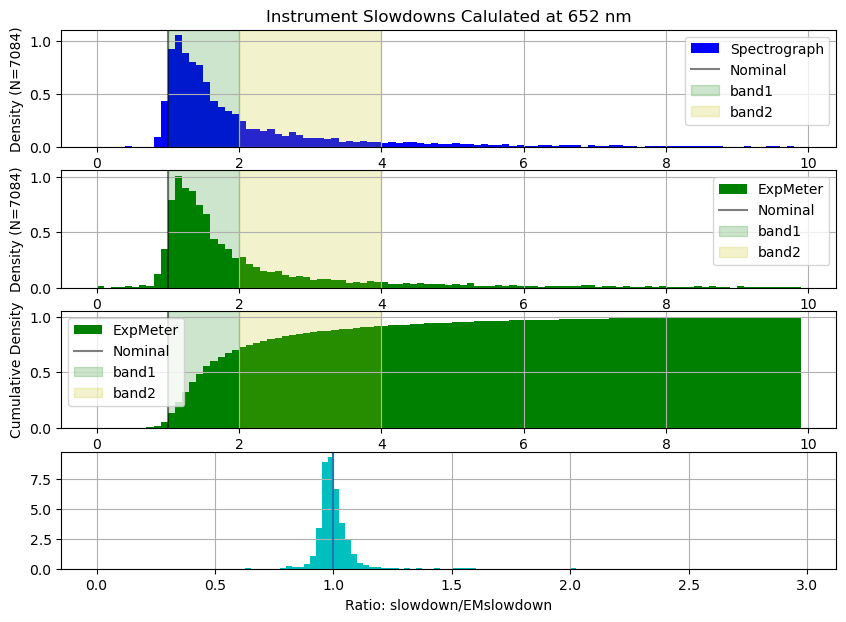

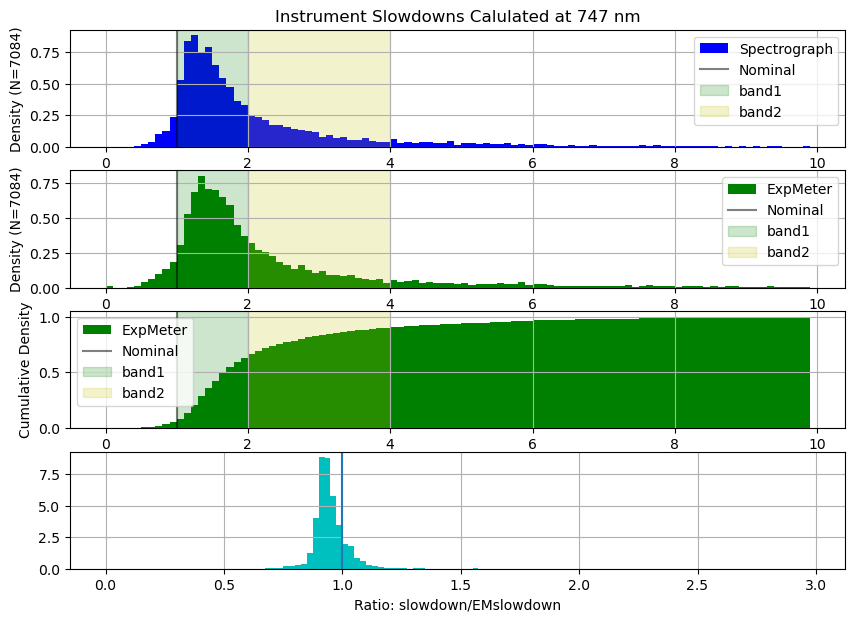

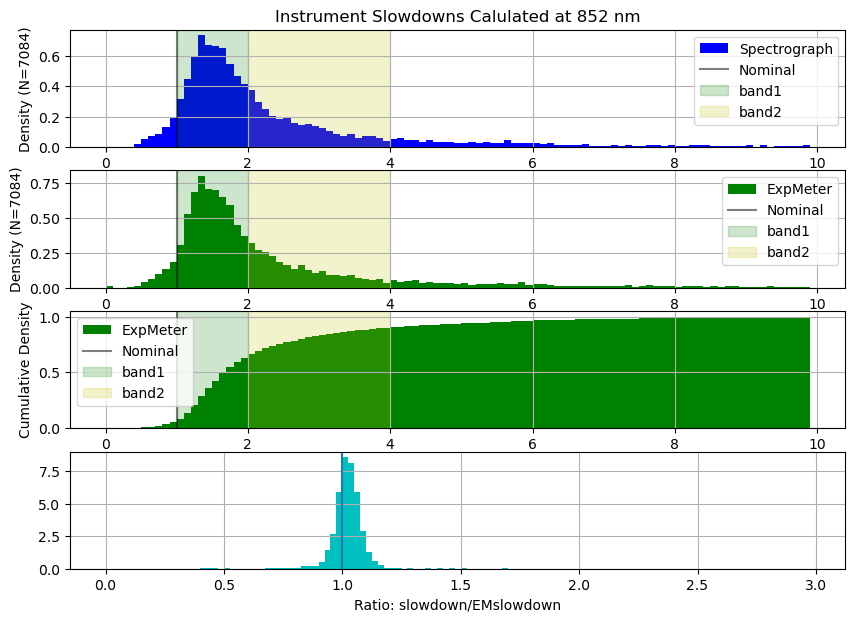

In [32]:
for instwav in instwavs:
    plot_slowdowns(instwav)

# Original KPF ETC

In [33]:
def get_GminusV(Teff):
    '''Table of data from:
    https://www.pas.rochester.edu/~emamajek/EEM_dwarf_UBVIJHK_colors_Teff.txt
    '''
    p = Path('~/git/KPFTranslator/kpf/calbench/').expanduser()
    table_file = p / 'EEM_dwarf_UBVIJHK_colors_Teff.txt'
    if table_file.exists() is False:
        return 0
    t = Table.read(table_file, format='ascii')
    filtered = t[t['G-V'] != '...']
    Teff_diff = abs(filtered['Teff'] - Teff)
    ind = np.argmin(Teff_diff)
    GminusV = float(filtered[ind]['G-V'])
    return GminusV

def Vmag(Gmag, Teff):
    return Gmag - get_GminusV(Teff)

In [34]:
def compare_ETCs(instwav, plot=True):
    order = {'452': 2,
             '548': 25,
             '652': 43,
             '747': 55,
             '852': 65}[instwav]
    Gmags = dataForExpMeter['GAIAMAG'].array
    exptimes = dataForExpMeter['ELAPSED'].array
    Teff = dataForExpMeter['TARGTEFF'].array
    ETCfluxes = []
    ZPETCfluxes = []
    instfluxes = []
    for i,Gmag in enumerate(Gmags):
        vmag = Vmag(Gmag, Teff[i])
        if Teff[i] > 2700 and Teff[i] < 6600 and exptimes[i] > 10 and exptimes[i] <= 3600:
            try:
                sigma_rv_val, wvl_arr, snr_ord, dv_ord = kpf_photon_noise_estimate(Teff[i], vmag, exptimes[i], quiet=True)
                ETCflux = snr_ord[order]**2
                ZPETCflux = ZPETC(Gmag, exptimes[i], instwav=instwav)[0]
                instflux = (dataForExpMeter[f'SNRSC{instwav}'].array[i])**2
                ETCfluxes.append(ETCflux)
                ZPETCfluxes.append(ZPETCflux)
                instfluxes.append(instflux)
            except Exception as e:
                print(e)
                print(Teff[i], vmag, exptimes[i])

    instfluxes = np.array(instfluxes)
    ETCfluxes = np.array(ETCfluxes)
    ZPETCfluxes = np.array(ZPETCfluxes)
    
    if plot:
        plt.figure(figsize=(10,3))
        bins = np.arange(0,10,0.10)
        plt.title(f'ETC Comparison: {instwav} nm')
        plt.hist(ETCfluxes/instfluxes, bins=bins, density=True, color='g', alpha=0.5, label='KPF-etc')
        plt.hist(ZPETCfluxes/instfluxes, bins=bins, density=True, color='b',alpha=0.5, label='ZP etc')
        plt.axvline(1, color='r')
        plt.grid()
        plt.legend(loc='best')
        plt.ylabel(f'Density')
        
        plt.xlabel('ETC Flux Overestimate (ETC/observed)')
        plt.show()
    return instfluxes, ETCfluxes, ZPETCfluxes

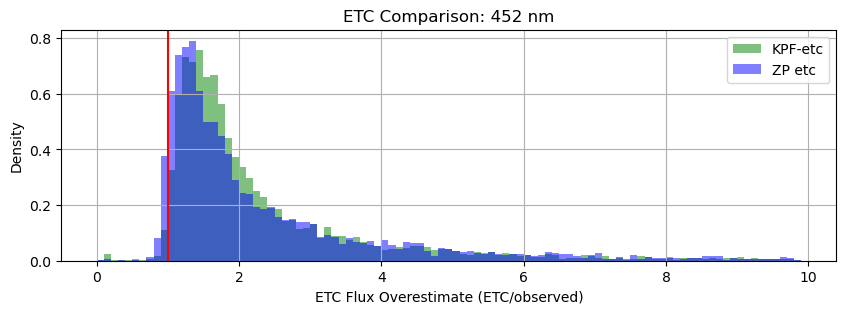

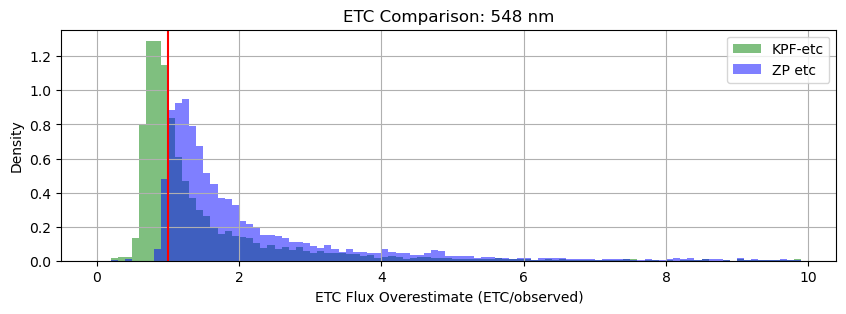

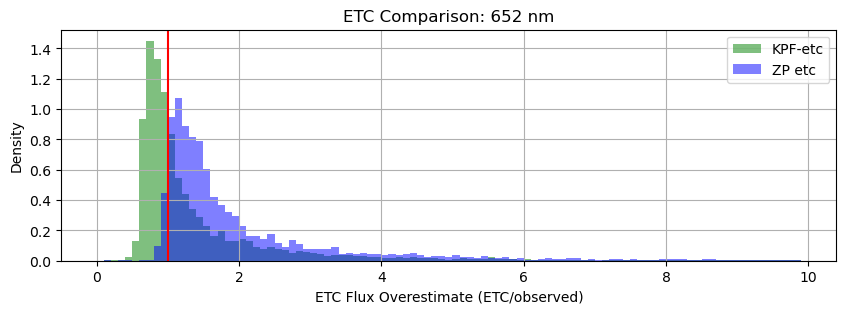

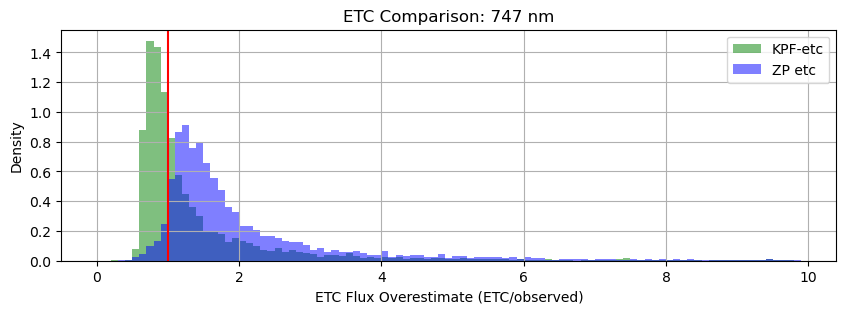

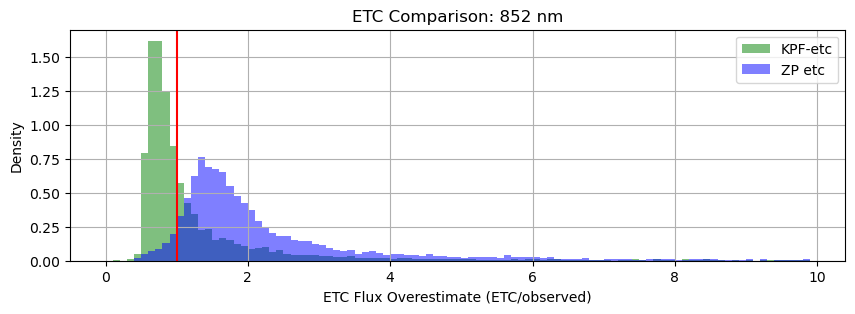

In [35]:
for instwav in instwavs:
    compare_ETCs(instwav)